## **visualization.py**

The pipeline has decided. Rider 7 was not wearing a helmet, across enough
frames, with enough confidence.

Now someone has to look at it. A violation that exists only as a `True` in a
dictionary isn't much use : the point of this system is to produce evidence a
human can review before anything becomes a ticket. This file turns pipeline state into pictures. Two functions: one crops a
license plate, one draws the full frame with every rider colour-coded by
status.

## **Setup**

In [1]:
!git clone -q https://github.com/shreyamali17/helmet-violation-detection.git
%cd helmet-violation-detection/project/pipeline
!pip install -q ultralytics scipy

/content/helmet-violation-detection/project/pipeline
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00


## **Cropping a plate**

Small function, and it exists to hand a tight image of a license plate to an
OCR step later.

In [2]:
import cv2

def crop_plate(frame_image, plate_box, padding=5):
    h, w = frame_image.shape[:2]
    x1, y1, x2, y2 = plate_box
    x1, y1 = max(0, int(x1)-padding), max(0, int(y1)-padding)
    x2, y2 = min(w, int(x2)+padding), min(h, int(y2)+padding)
    return frame_image[y1:y2, x1:x2]

### **The clamping**

```python
x1, y1 = max(0, int(x1)-padding), max(0, int(y1)-padding)
x2, y2 = min(w, int(x2)+padding), min(h, int(y2)+padding)
```

Padding widens the box slightly, because detection boxes tend to sit tight
against the plate and OCR does better with a margin.

But a plate detected at the very edge of the frame would push the padded box
outside the image. NumPy slicing doesn't raise on out-of-range indices it
silently returns a smaller array, or an empty one. The clamps keep the crop
inside the frame so downstream code gets what it expects.

`frame_image[y1:y2, x1:x2]` is rows first, then columns: **y before x**. That
ordering catches people out constantly, because box coordinates are written
x-first.

## **Drawing the frame**

The main function. Every rider gets a box coloured by their current status.

In [3]:
def draw_rm_instances(frame_image, det, instances_by_rider, highlight_rider_id=None):
    img = frame_image.copy()

    for rider_id, box in det["rider"].items():
        x1, y1, x2, y2 = map(int, box)
        inst = instances_by_rider.get(rider_id)

        if highlight_rider_id is not None and rider_id != highlight_rider_id:
            color, label, thickness = (140, 140, 140), "", 1
        elif inst is None:
            color, label, thickness = (150, 150, 150), f"rider {rider_id}", 2
        elif inst.is_violation is True:
            color, label, thickness = (0, 0, 255), f"rider {rider_id}: NO HELMET", 3
        elif inst.is_violation is False:
            color, label, thickness = (0, 200, 0), f"rider {rider_id}: helmet OK", 2
        else:
            color, label, thickness = (0, 165, 255), f"rider {rider_id}: pending", 2

        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        if label:
            cv2.putText(img, label, (x1, max(y1-10, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    for moto_id, box in det["motorcycle"].items():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 150, 0), 1)

    return img

### **`.copy()` on the first line**

```python
img = frame_image.copy()
```

OpenCV drawing functions modify the array in place. Without the copy, this
would scribble on `r.orig_img` the frame YOLO handed back and every later
use of that frame would carry the annotations.

In a loop that draws several times per frame, the boxes would accumulate.

### **The four states, and why they're four**

The `if` chain is the three-valued logic from `temporal.py` made visible:

| Colour | Meaning | `is_violation` |
|---|---|---|
| grey | seen, but no record yet | no instance |
| orange | tracked, still undecided | `None` |
| red | confirmed violation | `True` |
| green | confirmed compliant | `False` |

Note it tests `is True` and `is False` explicitly, not `if inst.is_violation`.
Since `None` and `False` are both falsy in Python, a plain truth test would
paint undecided riders green showing "confirmed helmet OK" for someone the
system hasn't judged.

That would be a quiet, plausible-looking bug in a system meant to produce
evidence.

### **BGR, not RGB**

```python
(0, 0, 255)   # red
(0, 200, 0)   # green
(0, 165, 255) # orange
```

OpenCV orders colour channels blue-green-red. So `(0, 0, 255)` is red, not
blue. Anything drawn with OpenCV and displayed with matplotlib needs
`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` first, or the colours invert.

### **The highlight parameter**

```python
if highlight_rider_id is not None and rider_id != highlight_rider_id:
    color, label, thickness = (140, 140, 140), "", 1
```

Two different jobs need two different pictures.

**No highlight** : every rider drawn in their own status colour. This is the
debugging view: what does the system currently believe about everyone in frame?

**With a highlight** : one rider in full colour, everyone else dimmed to thin
grey with no label. This is the evidence view.

The difference matters because a snapshot attached to a ticket should be
unambiguous about who it accuses. A frame with four red boxes raises the
question of which one the ticket is for.

## **Running the pipeline**

Enough state to draw something real.

In [4]:
from ultralytics import YOLO
import config
from detection import get_frame_detections
from association import associate_riders_to_motorcycles, associate_heads_to_riders
from rm_instance import RMInstanceManager
from temporal import smooth_helmet_status, decide_violation

model = YOLO(config.MODEL_PATH)

results = model.track(
    source=config.VIDEO_PATH,
    classes=list(config.CLASS_NAMES.keys()),
    tracker=config.TRACKER,
    persist=True, stream=True, verbose=False,
)

manager = RMInstanceManager()
observations = {}
frames = {}          # keep a few frames to draw later
FRAME_LIMIT = 300

for i, r in enumerate(results):
    if i >= FRAME_LIMIT:
        break

    det, confs = get_frame_detections(r)

    for rider_id, moto_id in associate_riders_to_motorcycles(det["rider"], det["motorcycle"]):
        manager.get_or_create(rider_id, moto_id)

    for rider_id, (status, conf) in associate_heads_to_riders(
            det["rider"], det["helmet"], det["no_helmet"],
            helmet_confs=confs["helmet"], no_helmet_confs=confs["no_helmet"]).items():
        observations.setdefault(rider_id, []).append((status, conf))

    for rider_id, inst in manager.instances_by_rider.items():
        smoothed = smooth_helmet_status(observations, rider_id)
        inst.is_violation = decide_violation(smoothed)

    # hold on to any frame showing a mix of states
    states = {inst.is_violation for inst in manager.instances_by_rider.values()}
    if len(states) >= 2 and len(frames) < 3:
        frames[i] = (r.orig_img.copy(), det)

print(manager.summary())
print("frames captured for drawing:", list(frames))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 444ms
Prepared 1 package in 52ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

{'total_instances': 39, 'confident_helmet_status': 0, 'confirmed_violations': 3}
frames captured for drawing: [2, 3, 4]


## **Debugging View**

Everyone in their own colour.

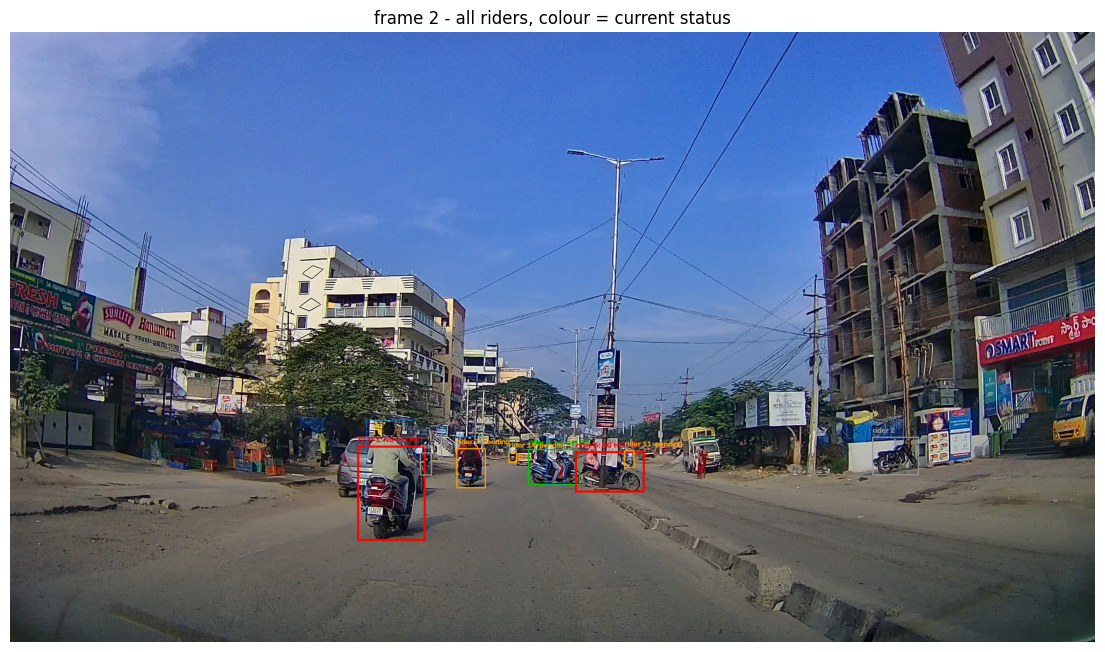

In [5]:
import matplotlib.pyplot as plt

frame_idx = list(frames)[0]
img, det_at_frame = frames[frame_idx]

annotated = draw_rm_instances(img, det_at_frame, manager.instances_by_rider)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"frame {frame_idx} - all riders, colour = current status")
plt.axis("off")
plt.show()

Orange boxes are the interesting ones: riders the system is still watching.
They may turn red or green in a later frame, or stay orange to the end of the
video if the evidence never gets strong enough.

A frame like this is a snapshot of an ongoing decision, not a final answer.

## **Evidence View**

Same frame, one rider highlighted.

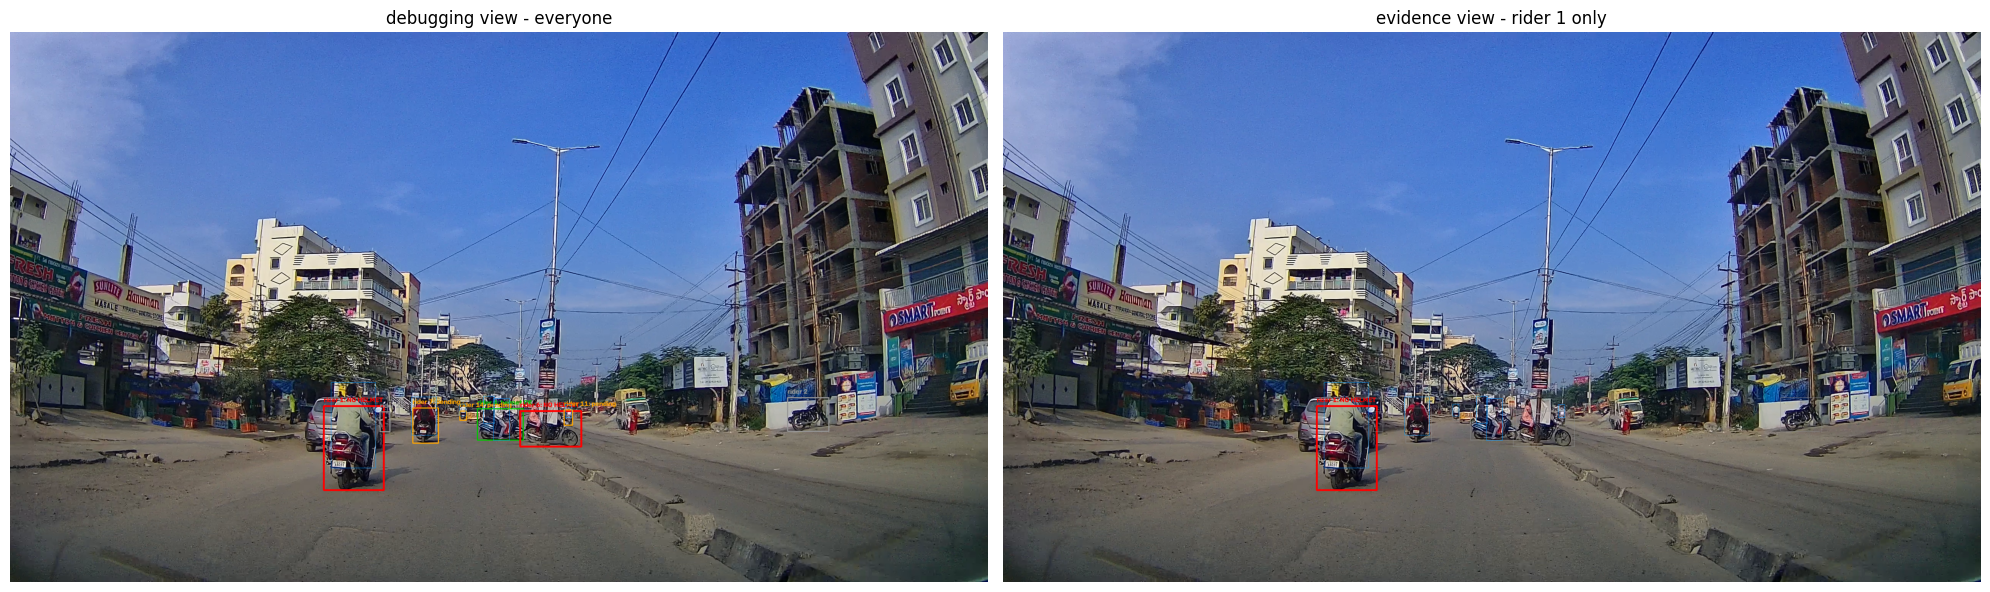

In [6]:
violators = [rid for rid, inst in manager.instances_by_rider.items()
             if inst.is_violation is True and rid in det_at_frame["rider"]]

if violators:
    target = violators[0]
    evidence = draw_rm_instances(img, det_at_frame, manager.instances_by_rider,
                                 highlight_rider_id=target)

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title("debugging view - everyone")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(evidence, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"evidence view - rider {target} only")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("no confirmed violator visible in this frame - try another from `frames`")

The right-hand image is what would be attached to a ticket. One rider named,
everyone else present for context but visibly not the subject.

## **Cropping a Plate from the Frame**

plate 9: box [843, 1120, 879, 1141]
crop size: 56 x 41 px


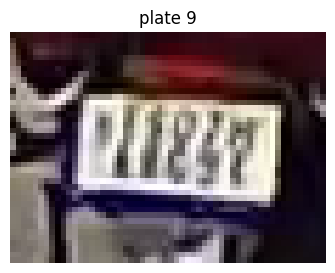

In [7]:
plates = det_at_frame["license_plate"]

if plates:
    pid = list(plates)[0]
    crop = crop_plate(img, plates[pid], padding=10)

    print(f"plate {pid}: box {[round(v) for v in plates[pid]]}")
    print(f"crop size: {crop.shape[1]} x {crop.shape[0]} px")

    plt.figure(figsize=(5, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"plate {pid}")
    plt.axis("off")
    plt.show()
else:
    print("no plates detected in this frame")

Plates at dashcam distance are typically a few dozen pixels wide. Whether
that's enough for OCR is the open question and one reason the OCR step
hasn't been wired in.

## **Try it**

**Break the three-valued test.** Change `elif inst.is_violation is False` to
`else` and redraw. Undecided riders turn green the system now shows
"confirmed helmet OK" for people it hasn't judged. This is what the explicit
`is` comparisons are protecting against.

**Swap the colours.** Set violations to `(255, 0, 0)` and see what renders.
BGR ordering means that's blue.

**Draw the whole video.** Write the annotated frames to an output video with
`cv2.VideoWriter` and watch riders change colour as evidence accumulates.
Orange turning red is the temporal logic becoming visible.

**Vary the padding.** Crop a plate at `padding=0` and `padding=30`. Which looks
more readable?

## **Next**

Each file so far does one job. `main.py` is the loop that runs all of them,
frame by frame, on a real video and produces the numbers that decide whether
this thing is fast enough for a Jetson.